# Lab 5: Clustering Techniques Using DBSCAN and Hierarchical Clustering

**Name:** Prakash Tamang  
**Course:** MSCS 634-M20 - Advanced Big Data and Data Mining  
**Instructor:** Dr. Satish Penmatsa  
**Assignment:** Lab 5: Clustering Techniques Using DBSCAN and Hierarchical Clustering

## Introduction

Clustering is an unsupervised learning technique used to group similar observations 
based on their characteristics. Unlike supervised learning methods, clustering 
does not rely on labeled outcomes but instead identifies natural patterns within 
the data.

This lab applies Hierarchical Clustering and DBSCAN to the Wine dataset available 
in the `sklearn` library. The objective is to observe how these algorithms form 
clusters, evaluate the quality of the clusters using quantitative metrics, and 
interpret the results through visualizations.

In [1]:
# Import libraries for data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import dataset and preprocessing tools
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

## Importing Required Libraries

The required Python libraries are imported for data analysis and visualization. 
The Wine dataset is loaded from the `sklearn` library, and `StandardScaler` 
is used to standardize the features before applying clustering algorithms.

In [2]:
# Load the Wine dataset
wine = load_wine()

# Convert the dataset into a pandas DataFrame
X = pd.DataFrame(wine.data, columns=wine.feature_names)

# Display the first few rows
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


## Loading the Dataset

The Wine dataset is loaded from the `sklearn.datasets` library. 
The dataset is converted into a pandas DataFrame so that it can be 
easily explored and analyzed.

In [3]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: float64(13)
m

In [4]:
X.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


## Dataset Structure and Summary Statistics

The dataset was examined using the `info()` and `describe()` functions in pandas. 
The `info()` output shows that the dataset contains 178 records and 13 numerical features, and no missing values are present. All variables are stored as floating-point numbers.

The `describe()` function provides summary statistics for each feature, including the mean, standard deviation, minimum, maximum, and quartile values. These statistics help understand the distribution and range of the variables before applying machine learning techniques.

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
import pandas as pd

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


## Feature Standardization

The dataset features were standardized using the `StandardScaler` method from the scikit-learn library. Standardization transforms the data so that each feature has a mean close to 0 and a standard deviation close to 1. 

The output shows that the values are now scaled around zero with both positive and negative values. This transformation ensures that all variables contribute equally to the clustering process, since clustering algorithms such as K-Means rely on distance calculations between data points.

In [10]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(n_clusters=3)
clusters = hierarchical.fit_predict(X_scaled)

clusters[:10]

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

## Hierarchical Clustering Implementation

Agglomerative Hierarchical Clustering was applied to the standardized dataset using three clusters. The algorithm groups similar data points by progressively merging the closest clusters until the specified number of clusters is reached. The output shows the cluster labels assigned to the first ten observations in the dataset.

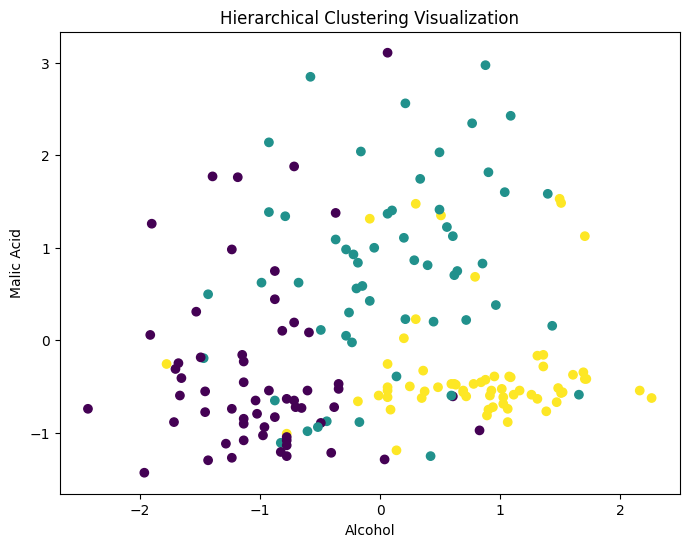

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(X_scaled['alcohol'], X_scaled['malic_acid'], c=clusters, cmap='viridis')

plt.xlabel('Alcohol')
plt.ylabel('Malic Acid')
plt.title('Hierarchical Clustering Visualization')

plt.show()

## Cluster Visualization

A scatter plot was used to visualize the hierarchical clustering results using the alcohol and malic_acid features. Each point represents a wine sample, and the colors indicate the cluster assigned by the algorithm. The plot shows how the samples are grouped into three clusters based on their similarity in these two features.

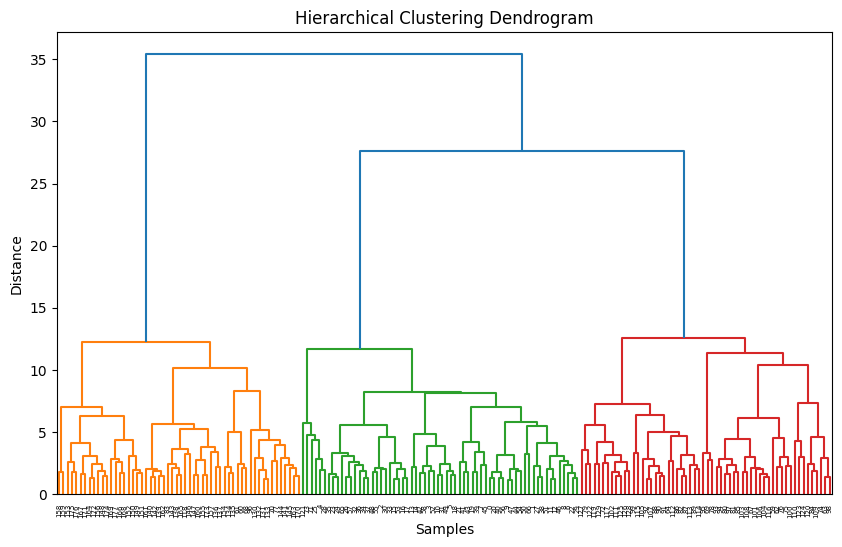

In [12]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,6))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

## Dendrogram Interpretation

The dendrogram visualizes the hierarchical structure of the dataset by showing how clusters merge at different distance levels. Each branch represents the merging of two clusters, and the vertical height indicates the distance between them. Larger vertical gaps suggest more distinct clusters. The dendrogram helps determine a reasonable number of clusters, and in this case the structure supports grouping the data into three main clusters.

In [13]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)
db_clusters = dbscan.fit_predict(X_scaled)

db_clusters[:10]

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

## DBSCAN Clustering

The DBSCAN algorithm was applied to the standardized dataset using eps = 1.5 and min_samples = 5. DBSCAN groups data points based on density and labels points that do not belong to any cluster as noise. In the output, the label -1 indicates noise points. This suggests that with the current parameter values many observations are not forming dense clusters.

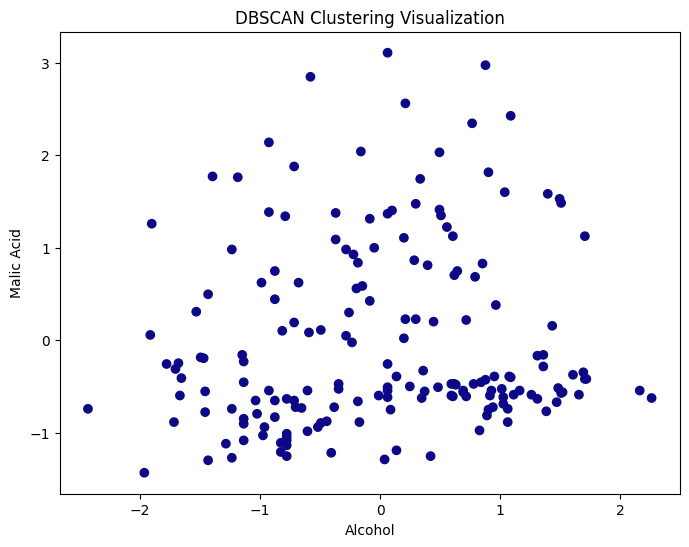

In [14]:
plt.figure(figsize=(8,6))
plt.scatter(X_scaled['alcohol'], X_scaled['malic_acid'], c=db_clusters, cmap='plasma')

plt.xlabel("Alcohol")
plt.ylabel("Malic Acid")
plt.title("DBSCAN Clustering Visualization")

plt.show()

## DBSCAN Cluster Visualization

The scatter plot shows the clustering results produced by the DBSCAN algorithm. In this case, most observations are labeled as noise because the current parameter settings do not identify dense regions in the dataset. DBSCAN assigns the label -1 to points that do not belong to any cluster. This result indicates that the chosen parameters may not be suitable and should be adjusted to detect meaningful clusters.

In [15]:
dbscan = DBSCAN(eps=2.5, min_samples=5)
db_clusters = dbscan.fit_predict(X_scaled)

db_clusters[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

## DBSCAN Parameter Adjustment

The DBSCAN parameters were adjusted by increasing eps from 1.5 to 2.5 while keeping min_samples equal to 5. With the larger neighborhood radius, the algorithm was able to group observations into a cluster instead of labeling them as noise. This demonstrates how DBSCAN results are highly dependent on the choice of parameters, especially the eps value.

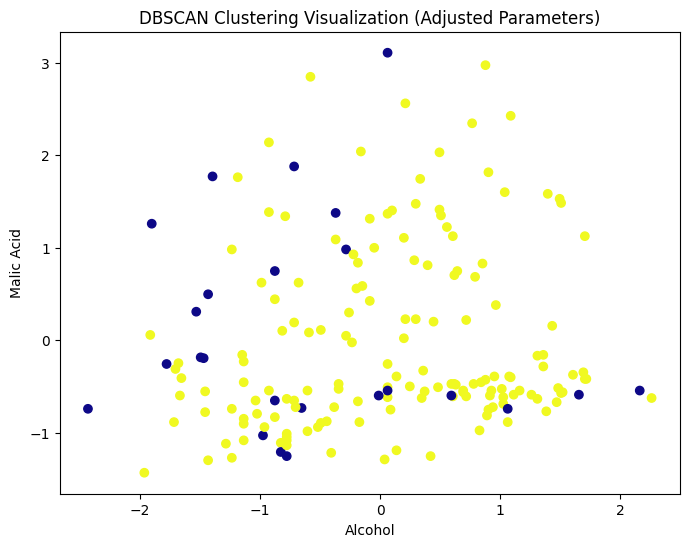

In [16]:
plt.figure(figsize=(8,6))
plt.scatter(X_scaled['alcohol'], X_scaled['malic_acid'], c=db_clusters, cmap='plasma')

plt.xlabel("Alcohol")
plt.ylabel("Malic Acid")
plt.title("DBSCAN Clustering Visualization (Adjusted Parameters)")

plt.show()

In [17]:
from sklearn.metrics import silhouette_score, homogeneity_score, completeness_score
from sklearn.datasets import load_wine

# true labels from dataset
wine = load_wine()
true_labels = wine.target

# metrics
sil_score = silhouette_score(X_scaled, db_clusters)
hom_score = homogeneity_score(true_labels, db_clusters)
comp_score = completeness_score(true_labels, db_clusters)

print("Silhouette Score:", sil_score)
print("Homogeneity Score:", hom_score)
print("Completeness Score:", comp_score)

Silhouette Score: 0.13500379635350565
Homogeneity Score: 0.05758801582121845
Completeness Score: 0.15814843013336194


## Clustering Evaluation Metrics

Three evaluation metrics were computed to assess the quality of the DBSCAN clustering results.

The Silhouette Score measures how well each data point fits within its assigned cluster compared to other clusters. The obtained value of approximately 0.135 indicates weak cluster separation, suggesting that the clusters are not strongly defined.

The Homogeneity Score evaluates whether each cluster contains only members of a single class. The score of about 0.058 indicates that the clusters contain mixed classes and are not well aligned with the true labels.

The Completeness Score measures whether all members of a given class are assigned to the same cluster. The value of approximately 0.158 suggests that samples belonging to the same class are spread across multiple clusters.

Overall, the evaluation results indicate that the DBSCAN clustering configuration did not produce highly distinct clusters for this dataset with the current parameter settings.

## Analysis and Insights

Both Hierarchical Clustering and DBSCAN were applied to the Wine dataset to explore different clustering approaches.

Hierarchical clustering produced clearer group structures, which could be observed in both the scatter plot visualization and the dendrogram. The dendrogram showed natural divisions in the dataset that supported grouping the observations into three clusters.

In contrast, DBSCAN was more sensitive to parameter selection. With a smaller eps value, most observations were labeled as noise. After increasing eps, the algorithm was able to group many points into a cluster, but the clusters were not strongly separated. This demonstrates that DBSCAN relies heavily on the density parameters used during clustering.

Hierarchical clustering is useful for understanding the hierarchical relationships among observations and for identifying natural cluster groupings. However, it can become computationally expensive for very large datasets. DBSCAN is advantageous because it can detect clusters of arbitrary shape and identify noise points, but it requires careful parameter tuning.

Based on the results obtained in this lab, hierarchical clustering provided clearer cluster separation for the Wine dataset, while DBSCAN struggled to identify well-defined clusters using the tested parameter values.